# QM640 Food Price Affordability AI
## Notebook 10 — Final Synopsis-Aligned Evidence Consolidation

This notebook verifies the complete Notebook 01–09 evidence chain, consolidates
the four original research questions and hypotheses, registers limitations,
creates report-ready tables and figures, and records the required GitHub
repository structure. It does not silently strengthen any upstream conclusion.


## 1. Setup and upstream verification


In [1]:
from pathlib import Path
import hashlib, json, os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 210)

try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = Path("/content/drive/MyDrive/QM640_Food_Affordability")
else:
    root = Path.cwd().resolve()
    if root.name == "notebooks": root = root.parent
    OUTPUT_ROOT = Path(os.environ.get("QM640_OUTPUT_ROOT", str(root)))

REPORT_OUTPUT = OUTPUT_ROOT / "reports" / "notebook_outputs"
FIGURES = REPORT_OUTPUT / "figures"
PROCESSED = OUTPUT_ROOT / "data" / "processed"
REPORT_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SKIP_PLOTS = os.environ.get("QM640_SKIP_PLOTS", "0") == "1"
if not SKIP_PLOTS:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")

summaries = {}
for number in range(1, 10):
    path = REPORT_OUTPUT / f"{number:02d}_execution_summary.json"
    if not path.exists():
        raise FileNotFoundError(f"Run aligned Notebook {number:02d} first: {path}")
    summaries[number] = json.loads(path.read_text(encoding="utf-8"))
    if summaries[number].get("status") not in {
        "completed", "completed_with_confirmatory_data_gaps",
        "completed_confirmatory_sources_present",
    }:
        raise AssertionError(f"Notebook {number:02d} did not complete: {summaries[number]}")
print("Verified upstream notebooks:", list(summaries))

nb01, nb02, nb03, nb04, nb05, nb06, nb07, nb08, nb09 = [
    summaries[i] for i in range(1, 10)
]


Mounted at /content/drive
Verified upstream notebooks: [1, 2, 3, 4, 5, 6, 7, 8, 9]


## 2. Original research questions and hypothesis decisions


In [2]:
rq_rows = [
    {
        "research_question": "RQ1",
        "question": "Which lagged-price, market-arrival, climatic, seasonal, agricultural-production, and macroeconomic variables significantly influence one- to three-month essential-food price changes in India?",
        "hypothesis": "H0-1: all driver coefficients are jointly zero; H1-1: at least one is nonzero.",
        "evidence": (
            "Available-variable joint H0 rejected at 1, 2 and 3 months. "
            f"{len(nb04['bh_significant_available_terms'])} BH-significant horizon-term results."
        ),
        "decision": "Reject available-variable H0-1 at all horizons; full original H0-1 remains partially unresolved.",
        "qualification": "Genuine market-arrival quantity is missing; conditional associations are not causal.",
        "primary_notebooks": "03, 04, 07",
    },
    {
        "research_question": "RQ2",
        "question": "Do machine-learning and ensemble models predict essential-food prices and price shocks more accurately than conventional statistical forecasting models?",
        "hypothesis": "H0-2: ML forecast loss is not lower; H1-2: at least one ML model has lower loss.",
        "evidence": (
            "Histogram gradient boosting had the lowest RMSE at all three horizons, "
            "but Holm-adjusted paired tests were not significant."
        ),
        "decision": "Fail to reject H0-2 at 1, 2 and 3 months.",
        "qualification": "Eight chronological origins; model selection does not itself prove significant superiority.",
        "primary_notebooks": "05, 06, 07",
    },
    {
        "research_question": "RQ3",
        "question": "How can forecasted commodity-price changes be translated into a statistically reliable, interpretable, and stable HFASI across rural, urban, and expenditure segments?",
        "hypothesis": "H0-3: no construct validity/stable ranking; H1-3: valid and stable segment ranking.",
        "evidence": (
            f"HCES Engel-law rho={nb08['construct_validity_spearman_rho']:.3f}; "
            f"mean rank stability={nb08['mean_monthly_rank_stability']:.3f}."
        ),
        "decision": nb08["rq3_hypothesis_decision"],
        "qualification": "Disclosure-safe segment aggregates; not household-level welfare classification.",
        "primary_notebooks": "08",
    },
    {
        "research_question": "RQ4",
        "question": "How effectively can the framework support household budgeting, retail inventory, enterprise procurement, and policy monitoring under alternative scenarios?",
        "hypothesis": "H0-4: model warnings do not reduce decision loss; H1-4: paired loss is reduced.",
        "evidence": nb09["overall_rq4_conclusion"],
        "decision": "; ".join(f"{k}: {v}" for k, v in nb09["rq4_decisions"].items()),
        "qualification": "Loss weights are relative utilities; forward scenarios are controlled assumptions, not forecasts.",
        "primary_notebooks": "09",
    },
]
research_questions = pd.DataFrame(rq_rows)
research_questions.to_csv(REPORT_OUTPUT / "10_research_question_hypothesis_map.csv", index=False)
print(research_questions[["research_question", "decision", "qualification"]].to_string(index=False))


research_question                                                                                                                                                                       decision                                                                                     qualification
              RQ1                                                                               Reject available-variable H0-1 at all horizons; full original H0-1 remains partially unresolved.              Genuine market-arrival quantity is missing; conditional associations are not causal.
              RQ2                                                                                                                                      Fail to reject H0-2 at 1, 2 and 3 months.       Eight chronological origins; model selection does not itself prove significant superiority.
              RQ3                                                                                                              

## 3. Consolidated key findings and model scorecard


In [3]:
model_metrics = pd.read_csv(REPORT_OUTPUT / "05_panel_model_metrics.csv")
shock_metrics = pd.read_csv(REPORT_OUTPUT / "06_shock_classifier_metrics.csv")
decision_loss = pd.read_csv(REPORT_OUTPUT / "09_retrospective_decision_loss.csv")
joint_tests = pd.read_csv(REPORT_OUTPUT / "04_joint_hypothesis_tests.csv")

selected_forecast_rows = []
for horizon in [1, 2, 3]:
    model = nb05["selected_models_by_horizon"][f"{horizon}_month"]
    row = model_metrics.loc[
        model_metrics["horizon_months"].eq(horizon) & model_metrics["model"].eq(model)
    ].iloc[0]
    selected_forecast_rows.append({
        "component": f"{horizon}-month price-change forecast",
        "selected_method": model,
        "primary_metric": "RMSE",
        "metric_value": float(row["rmse"]),
        "validation": f"{nb05['rolling_origins']} expanding chronological origins",
        "decision_use": "State–commodity monitoring",
    })
for horizon in [1, 2, 3]:
    model = nb06["selected_models"][f"{horizon}_month"]
    row = shock_metrics.loc[
        shock_metrics["horizon_months"].eq(horizon) & shock_metrics["model"].eq(model)
    ].iloc[0]
    selected_forecast_rows.append({
        "component": f"{horizon}-month price-shock classification",
        "selected_method": model,
        "primary_metric": "Average precision",
        "metric_value": float(row["average_precision"]),
        "validation": f"{nb06['rolling_origins']} expanding chronological origins",
        "decision_use": "Rare-event risk watch",
    })
selected_forecast_rows += [
    {
        "component": "24-month national CPI planning path",
        "selected_method": nb05["national_forecast_model"],
        "primary_metric": "Conditional horizon",
        "metric_value": float(nb05["national_forecast_horizon_months"]),
        "validation": "ETS fit plus approximate expanding uncertainty",
        "decision_use": "Planning scenario; not guaranteed forecast",
    },
    {
        "component": "Household affordability",
        "selected_method": "HCES-derived HFASI",
        "primary_metric": "Construct-validity Spearman rho",
        "metric_value": float(nb08["construct_validity_spearman_rho"]),
        "validation": "2,000 row-bootstrap replications and rank stability",
        "decision_use": "Representative segment stress",
    },
]
scorecard = pd.DataFrame(selected_forecast_rows)
scorecard.to_csv(REPORT_OUTPUT / "10_model_scorecard.csv", index=False)

key_findings = pd.DataFrame([
    ["Data", "Clean state–month–commodity observations", nb02["clean_state_rows"], "32 reporting states/UTs; 8 commodities"],
    ["Data", "Underlying official price observations", nb01["agmarknet_underlying_official_observations"], "Aggregated to daily/monthly panels"],
    ["RQ1", "Available-variable joint tests rejected", 3, "1-, 2-, and 3-month horizons"],
    ["RQ2", "ML superiority tests rejecting H0-2", 0, "All Holm-adjusted p-values equal 1.0"],
    ["Shock monitoring", "Highest forward conditional risk", nb06["highest_forward_risk"], f"{nb06['highest_forward_risk_region']} — {nb06['highest_forward_risk_commodity']}"],
    ["RQ3", "HCES households represented", nb08["hces_sample_households_represented"], "Disclosure-safe state/sector/decile aggregates"],
    ["RQ3", "HFASI construct validity rho", nb08["construct_validity_spearman_rho"], "Strong negative MPCE–food-share association"],
    ["RQ3", "Highest 24-month HFASI", nb08["highest_hfasi"], f"{nb08['highest_hfasi_state']}, {nb08['highest_hfasi_sector']}, decile {nb08['highest_hfasi_decile']}"],
    ["RQ4", "Stakeholders with significant loss reduction", nb09["stakeholders_rejecting_h0_4"], "Holm-adjusted paired decision tests"],
    ["Scenario", "Highest scenario shock probability", nb09["highest_scenario_shock_probability"], "Controlled what-if scenario"],
], columns=["domain", "finding", "value", "scope"])
key_findings.to_csv(REPORT_OUTPUT / "10_key_findings.csv", index=False)
print(scorecard.round(4).to_string(index=False))
print("\nKey findings")
print(key_findings.to_string(index=False))


                          component        selected_method                  primary_metric  metric_value                                          validation                               decision_use
      1-month price-change forecast hist_gradient_boosting                            RMSE      126.7894                   8 expanding chronological origins                 State–commodity monitoring
      2-month price-change forecast hist_gradient_boosting                            RMSE       35.8110                   8 expanding chronological origins                 State–commodity monitoring
      3-month price-change forecast hist_gradient_boosting                            RMSE       34.7553                   8 expanding chronological origins                 State–commodity monitoring
 1-month price-shock classification hist_gradient_boosting               Average precision        0.3307                   8 expanding chronological origins                      Rare-event risk watch


## 4. Limitations, mitigation and next-stage work


In [4]:
limitations = pd.DataFrame([
    ["Market arrivals", "No genuine arrival/traded-quantity series was acquired.", "Full RQ1 supply-side hypothesis remains partially unresolved.", "Obtain e-NAM/AGMARKNET quantity export and rerun 01–07."],
    ["Rural wages", "Labour Bureau export covers only part of FY2025-26.", "Wage effects are supplementary and not historical.", "Acquire full 2006–2026 monthly table."],
    ["Climate representation", "NASA POWER uses representative administrative-capital points.", "Not an area-weighted state climate estimate.", "Replace/validate with IMD gridded state aggregates."],
    ["Reporting coverage", "Coverage is important in several predictive models.", "Reporting changes may resemble economic signals.", "Retain coverage controls and perform stable-market sensitivity analysis."],
    ["Forecast validation", "Only eight aligned chronological origins were used.", "Tail performance and regime stability are uncertain.", "Expand origins and add commodity-specific calibration."],
    ["Rare events", "Shock samples range from 60 to 73 events per horizon.", "Precision and recall remain sampling-sensitive.", "Report PR metrics and bootstrap intervals; avoid automation."],
    ["HFASI scope", "Uses disclosure-safe HCES segment aggregates.", "Cannot classify individual households or establish welfare thresholds.", "Validate on authorized household microdata in a secure environment."],
    ["Causality", "Regression and explainability outputs are associational.", "Drivers cannot be treated as intervention effects.", "Use causal designs only when identification assumptions are defensible."],
    ["Scenario assumptions", "Price overlays and probability multipliers are controlled assumptions.", "Scenario outputs are model- and assumption-sensitive.", "Calibrate assumptions with stakeholder and policy experts."],
], columns=["area", "limitation", "impact", "mitigation"])
limitations.to_csv(REPORT_OUTPUT / "10_limitations_register.csv", index=False)

next_steps = pd.DataFrame([
    [1, "Acquire genuine arrivals and complete rural-wage history", "Close remaining confirmatory gaps", "High"],
    [2, "Extend rolling-origin and commodity-specific validation", "Increase forecast reliability", "High"],
    [3, "Calibrate decision-loss weights with stakeholders", "Translate relative losses into operational costs", "High"],
    [4, "Secure household-level HFASI validation", "Test within-state/sector household discrimination", "Medium"],
    [5, "Replace point climate with IMD area-weighted measures", "Improve physical interpretation", "Medium"],
    [6, "Build monitored dashboard with drift and coverage alerts", "Operational demonstration", "Medium"],
], columns=["sequence", "next_stage_task", "purpose", "priority"])
next_steps.to_csv(REPORT_OUTPUT / "10_next_stage_workplan.csv", index=False)
print(limitations.to_string(index=False))


                  area                                                             limitation                                                                 impact                                                               mitigation
       Market arrivals                No genuine arrival/traded-quantity series was acquired.          Full RQ1 supply-side hypothesis remains partially unresolved.                  Obtain e-NAM/AGMARKNET quantity export and rerun 01–07.
           Rural wages                    Labour Bureau export covers only part of FY2025-26.                     Wage effects are supplementary and not historical.                                    Acquire full 2006–2026 monthly table.
Climate representation          NASA POWER uses representative administrative-capital points.                           Not an area-weighted state climate estimate.                      Replace/validate with IMD gridded state aggregates.
    Reporting coverage                    Covera

## 5. GitHub repository structure and reproducibility inventory


In [5]:
REPOSITORY_URL = "https://github.com/piyushsoni88/qm640-food-affordability-ai"
repository_structure = pd.DataFrame([
    ["README.md", "Project overview, environment and execution order"],
    ["notebooks/01...10_synopsis_aligned.ipynb", "Executable Colab analysis chain"],
    ["data/curated/", "Shareable official aggregates and source documentation"],
    ["data/processed/", "Clean modeled panels; compressed where appropriate"],
    ["data/external_required/", "Shareable disclosure-safe APY, wage and HCES aggregates"],
    ["data/raw/", "Ignored local restricted/source archives; never publish HCES/PLFS unit records"],
    ["reports/notebook_outputs/", "Tables, summaries and figures generated by notebooks"],
    ["reports/", "Interim report and final deliverables"],
    ["scripts/", "Deterministic notebook/data/report builders"],
], columns=["path", "purpose"])
repository_structure["repository_url"] = REPOSITORY_URL
repository_structure.to_csv(REPORT_OUTPUT / "10_repository_structure.csv", index=False)

artifact_rows = []
for folder in [PROCESSED, REPORT_OUTPUT]:
    for path in sorted(folder.rglob("*")):
        if path.is_file():
            digest = hashlib.sha256(path.read_bytes()).hexdigest()
            artifact_rows.append({
                "relative_path": str(path.relative_to(OUTPUT_ROOT)).replace("\\", "/"),
                "size_bytes": path.stat().st_size,
                "sha256": digest,
            })
artifact_inventory = pd.DataFrame(artifact_rows)
artifact_inventory.to_csv(REPORT_OUTPUT / "10_artifact_inventory.csv", index=False)
print(repository_structure.to_string(index=False))
print(f"\nInventoried reproducible artifacts: {len(artifact_inventory)}")


                                    path                                                                        purpose                                              repository_url
                               README.md                              Project overview, environment and execution order https://github.com/piyushsoni88/qm640-food-affordability-ai
notebooks/01...10_synopsis_aligned.ipynb                                                Executable Colab analysis chain https://github.com/piyushsoni88/qm640-food-affordability-ai
                           data/curated/                         Shareable official aggregates and source documentation https://github.com/piyushsoni88/qm640-food-affordability-ai
                         data/processed/                             Clean modeled panels; compressed where appropriate https://github.com/piyushsoni88/qm640-food-affordability-ai
                 data/external_required/                        Shareable disclosure-safe APY, wage 

## 6. Interim-report compliance checklist and consolidated figure


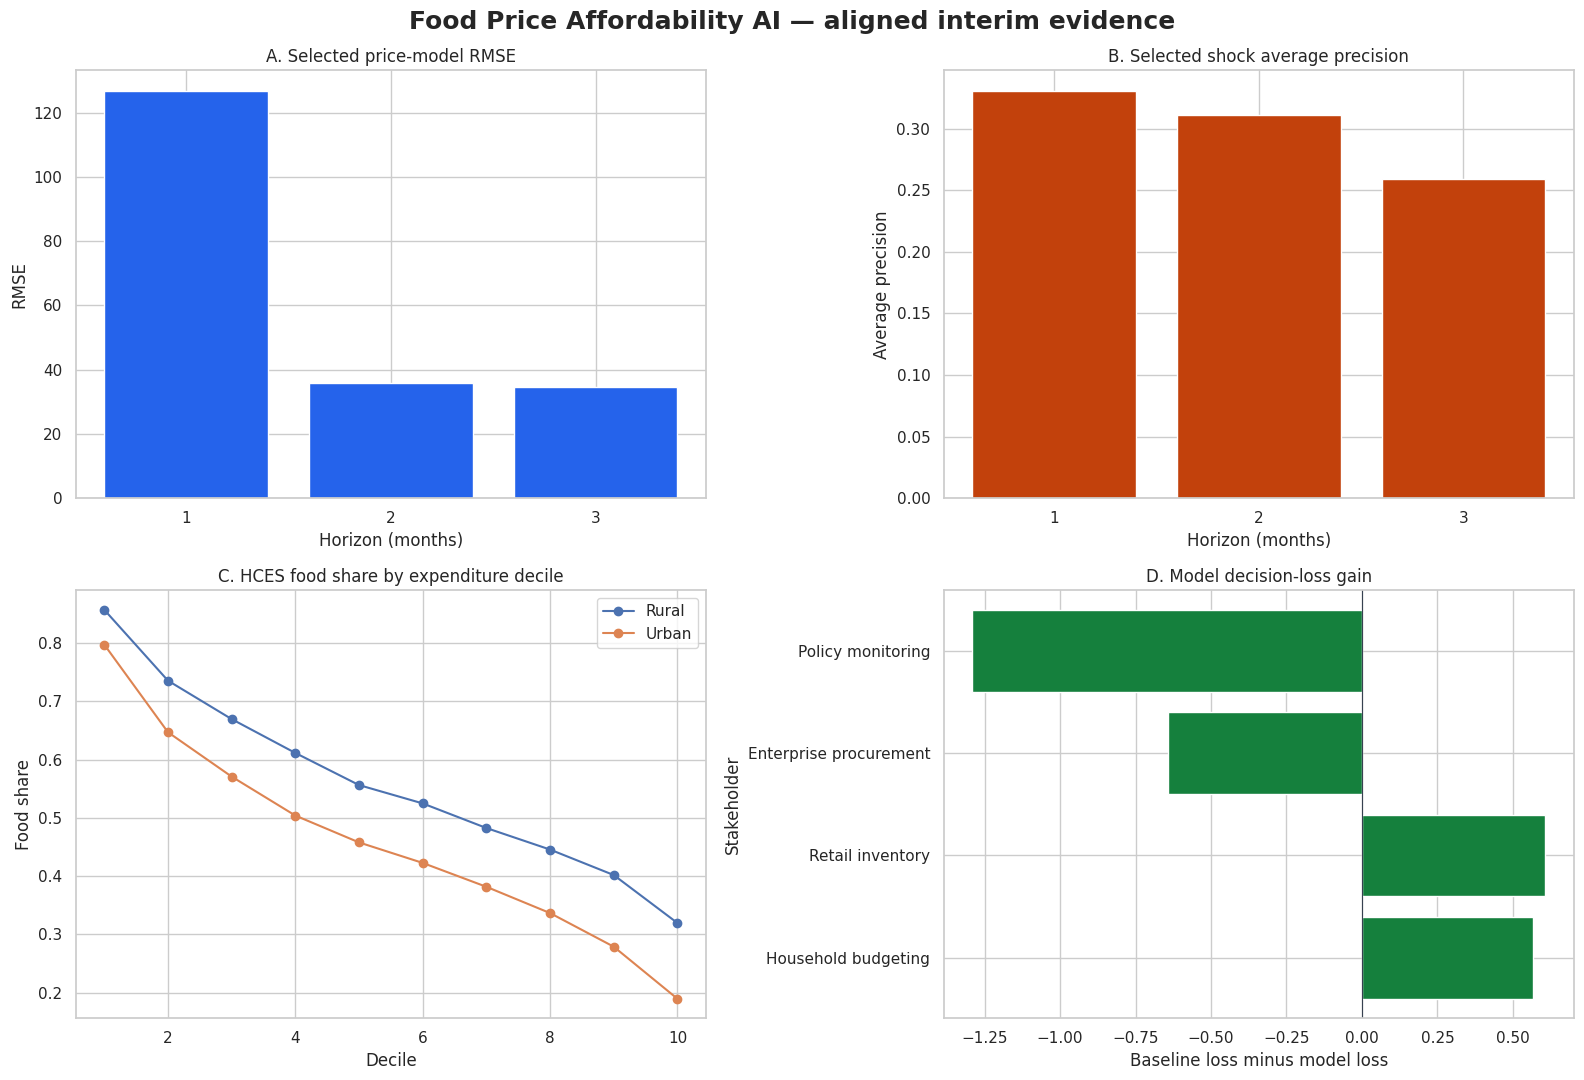

In [6]:
report_checklist = pd.DataFrame([
    ["Title/project identity", True, "Cover page and repository URL"],
    ["Problem statement and motivation", True, "Original synopsis preserved"],
    ["Research questions and hypotheses", True, "Four RQs and four hypothesis pairs mapped"],
    ["Literature/theoretical basis", True, "To be retained from synopsis and updated in report"],
    ["Data sources and variable definitions", True, "Official-source audit plus variable matrix"],
    ["Data quality and preprocessing", True, "Notebooks 01–02"],
    ["Exploratory results", True, "Notebook 03"],
    ["Statistical hypothesis tests", True, "Notebook 04"],
    ["Forecast and shock models", True, "Notebooks 05–06"],
    ["Explainability", True, "Notebook 07"],
    ["Affordability index validity", True, "Notebook 08"],
    ["Decision scenarios", True, "Notebook 09"],
    ["Limitations and ethics", True, "Registered explicitly"],
    ["Work completed and next-stage plan", True, "Artifact inventory and workplan"],
    ["GitHub structure and links", True, REPOSITORY_URL],
], columns=["template_requirement", "available", "evidence"])
report_checklist.to_csv(REPORT_OUTPUT / "10_interim_report_checklist.csv", index=False)

if not SKIP_PLOTS:
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    selected_metrics = model_metrics.loc[
        model_metrics.apply(
            lambda r: r["model"] == nb05["selected_models_by_horizon"][f"{int(r['horizon_months'])}_month"],
            axis=1,
        )
    ]
    axes[0, 0].bar(selected_metrics["horizon_months"].astype(str), selected_metrics["rmse"], color="#2563eb")
    axes[0, 0].set(title="A. Selected price-model RMSE", xlabel="Horizon (months)", ylabel="RMSE")

    selected_shocks = shock_metrics.loc[
        shock_metrics.apply(
            lambda r: r["model"] == nb06["selected_models"][f"{int(r['horizon_months'])}_month"],
            axis=1,
        )
    ]
    axes[0, 1].bar(selected_shocks["horizon_months"].astype(str), selected_shocks["average_precision"], color="#c2410c")
    axes[0, 1].set(title="B. Selected shock average precision", xlabel="Horizon (months)", ylabel="Average precision")

    deciles = pd.read_csv(REPORT_OUTPUT / "08_hces_decile_profile.csv")
    for sector, group in deciles.groupby("sector"):
        axes[1, 0].plot(group["expenditure_decile"], group["weighted_food_share"], marker="o", label=sector)
    axes[1, 0].set(title="C. HCES food share by expenditure decile", xlabel="Decile", ylabel="Food share")
    axes[1, 0].legend()

    axes[1, 1].barh(decision_loss["stakeholder"], decision_loss["mean_loss_gain"], color="#15803d")
    axes[1, 1].axvline(0, color="#374151", linewidth=0.8)
    axes[1, 1].set(title="D. Model decision-loss gain", xlabel="Baseline loss minus model loss", ylabel="Stakeholder")
    fig.suptitle("Food Price Affordability AI — aligned interim evidence", fontsize=18, fontweight="bold")
    fig.tight_layout()
    fig.savefig(FIGURES / "10_aligned_consolidated_results.png", bbox_inches="tight")
    plt.show()


## 7. Execution summary and report hand-off


In [7]:
summary = {
    "notebook": "10_final_results_synopsis_aligned",
    "status": "completed",
    "upstream_notebooks_verified": 9,
    "original_research_questions_preserved": 4,
    "hypothesis_pairs_mapped": 4,
    "key_findings_consolidated": int(len(key_findings)),
    "limitations_registered": int(len(limitations)),
    "next_stage_tasks": int(len(next_steps)),
    "artifacts_in_inventory": int(len(artifact_inventory)),
    "rq1_decision": research_questions.loc[0, "decision"],
    "rq2_decision": research_questions.loc[1, "decision"],
    "rq3_decision": research_questions.loc[2, "decision"],
    "rq4_decision": nb09["overall_rq4_conclusion"],
    "highest_forward_shock_probability": float(nb06["highest_forward_risk"]),
    "highest_forward_shock_case": f"{nb06['highest_forward_risk_region']} — {nb06['highest_forward_risk_commodity']}",
    "hfasi_construct_validity_rho": float(nb08["construct_validity_spearman_rho"]),
    "highest_hfasi": float(nb08["highest_hfasi"]),
    "repository_url": REPOSITORY_URL,
    "report_checklist_complete": bool(report_checklist["available"].all()),
    "report_readiness": (
        "Aligned evidence chain complete; narrative must retain all qualifications "
        "and keep the main report within 15–16 pages excluding appendices."
    ),
    "output_root": str(OUTPUT_ROOT),
}
SUMMARY_FILE = REPORT_OUTPUT / "10_execution_summary.json"
SUMMARY_FILE.write_text(json.dumps(summary, indent=2), encoding="utf-8")

brief = "\n".join([
    "# QM640 Aligned Interim Evidence Brief",
    "",
    "## Hypothesis decisions",
    "",
    f"- RQ1: {summary['rq1_decision']}",
    f"- RQ2: {summary['rq2_decision']}",
    f"- RQ3: {summary['rq3_decision']}",
    f"- RQ4: {summary['rq4_decision']}",
    "",
    "## Required qualifications",
    "",
    "- Market-arrival quantity remains missing.",
    "- Rural-wage coverage is partial.",
    "- Predictive and statistical relationships are not causal.",
    "- HFASI is a representative segment index, not a household welfare threshold.",
    "- Forward scenario assumptions are not forecasts.",
    "",
    f"Repository: {REPOSITORY_URL}",
])
(REPORT_OUTPUT / "10_interim_evidence_brief.md").write_text(brief, encoding="utf-8")

expected = [
    REPORT_OUTPUT / "10_research_question_hypothesis_map.csv",
    REPORT_OUTPUT / "10_model_scorecard.csv",
    REPORT_OUTPUT / "10_key_findings.csv",
    REPORT_OUTPUT / "10_limitations_register.csv",
    REPORT_OUTPUT / "10_next_stage_workplan.csv",
    REPORT_OUTPUT / "10_repository_structure.csv",
    REPORT_OUTPUT / "10_artifact_inventory.csv",
    REPORT_OUTPUT / "10_interim_report_checklist.csv",
    REPORT_OUTPUT / "10_interim_evidence_brief.md",
    SUMMARY_FILE,
]
if not SKIP_PLOTS: expected.append(FIGURES / "10_aligned_consolidated_results.png")
missing = [str(p) for p in expected if not p.exists()]
if missing: raise FileNotFoundError("\n".join(missing))
print("=" * 76)
print("NOTEBOOK 10 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT")
print("=" * 76)
print(json.dumps(summary, indent=2))
print(f"\nVerified final artifacts: {len(expected)}")


NOTEBOOK 10 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT
{
  "notebook": "10_final_results_synopsis_aligned",
  "status": "completed",
  "upstream_notebooks_verified": 9,
  "original_research_questions_preserved": 4,
  "hypothesis_pairs_mapped": 4,
  "key_findings_consolidated": 10,
  "limitations_registered": 9,
  "next_stage_tasks": 6,
  "artifacts_in_inventory": 155,
  "rq1_decision": "Reject available-variable H0-1 at all horizons; full original H0-1 remains partially unresolved.",
  "rq2_decision": "Fail to reject H0-2 at 1, 2 and 3 months.",
  "rq3_decision": "provisional_reject_H0_3_construct_valid_and_stable",
  "rq4_decision": "partial_support_model_warnings_reduce_loss_for_one_or_more_stakeholders",
  "highest_forward_shock_probability": 0.820457860788071,
  "highest_forward_shock_case": "Delhi \u2014 Rice",
  "hfasi_construct_validity_rho": -0.8841472075373542,
  "highest_hfasi": 103.49436982006,
  "repository_url": "https://github.com/piyushsoni88/qm640-food-afforda

## Notebook 10 conclusion

The aligned interim evidence chain is complete. The final report must reproduce
the original research questions and hypotheses, report negative or qualified
findings as obtained, and distinguish prediction, association, construct
validity and scenario demonstration. Appendices may contain detailed tables;
the substantive main report must remain within 15–16 pages.
